# 3. Desarrollo
## 3.1 Algoritmo: Gale-Shapley Ordenado

1. Ordenar las preferencias de hospitales usando Merge Sort.

2. Convertir las preferencias ordenadas de hospitales a listas que contengan solo los nombres de los alumnos.

3. Ordenar las preferencias de alumnos usando Merge Sort.

4. Convertir las preferencias ordenadas de alumnos a listas que contengan solo los nombres de los hospitales.

5. Aplicar el algoritmo Gale-Shapley:

   a. Crear una lista con todos los hospitales libres.

   b. Mientras existan hospitales libres:

      i. Tomar el primer hospital libre.

      ii. Obtener al siguiente alumno al que ese hospital debe proponerle.

      iii. Si el alumno no está emparejado, se empareja con ese hospital.

      iv. Si el alumno ya está emparejado, se compara el hospital actual con el nuevo hospital.

      v. Si el alumno prefiere al nuevo hospital, cambia de emparejamiento y el hospital anterior vuelve a quedar libre.

      vi. Si el alumno prefiere al hospital actual, rechaza al nuevo hospital y este vuelve a quedar libre.

6. Guardar el emparejamiento final en un diccionario donde cada hospital queda asociado con un alumno.

7. Mostrar las preferencias ordenadas de hospitales, las preferencias ordenadas de alumnos y el emparejamiento final.



## 3.2 Descripción de funciones

### 3.2.1 `merge_sort(st)`

Esta función recibe una lista de tuplas y la ordena de mayor a menor tomando como referencia el segundo valor de cada tupla, que representa el puntaje de preferencia.

Primero verifica si la lista tiene uno o ningún elemento. En ese caso, la lista ya está ordenada y se retorna directamente.

Si la lista tiene más de un elemento, se divide en dos mitades: izquierda y derecha. Después, la función se llama recursivamente para ordenar cada mitad. Finalmente, ambas mitades ordenadas se combinan mediante la función `merge`.

---

### 3.2.2 `merge(izq, der)`

Esta función recibe dos listas previamente ordenadas y las combina en una sola lista ordenada de mayor a menor.

Para hacer esto, compara los puntajes de los elementos de ambas listas. Si el puntaje del elemento de la lista izquierda es mayor que el de la lista derecha, se agrega primero el elemento de la izquierda. En caso contrario, se agrega el elemento de la derecha.

Cuando una de las dos listas se termina, los elementos restantes de la otra lista se agregan directamente al resultado final.

---

### 3.2.3 `obtener_nombres(preferencias)`

Esta función recibe un diccionario de preferencias, donde cada clave representa a una persona o institución, y cada valor es una lista de tuplas con el nombre de la opción y su puntaje.

La función ordena cada lista de preferencias usando `merge_sort`. Después, crea una nueva lista que contiene únicamente los nombres, eliminando los puntajes.

Finalmente, retorna un nuevo diccionario con las preferencias ordenadas, pero representadas solo por nombres.

---

### 3.2.4 `gale_shapley(hospitales, alumnos)`

Esta función aplica el algoritmo de Gale-Shapley para obtener un emparejamiento estable entre hospitales y alumnos.

Primero se crea una lista con todos los hospitales libres. También se crea un diccionario llamado `emparejamiento`, donde se guardan las asignaciones temporales entre alumnos y hospitales.

Después, se crea el diccionario `siguiente_propuesta`, que permite llevar el control de a qué alumno debe proponerle cada hospital en cada turno.

También se genera el diccionario `nivel_preferencias`, el cual permite conocer rápidamente qué hospital prefiere más cada alumno, de acuerdo con la posición que ocupa cada hospital en su lista de preferencias.

Mientras existan hospitales libres, se toma un hospital de la lista y este propone al siguiente alumno disponible en su lista de preferencias.

Si el alumno no está emparejado, acepta la propuesta del hospital. Si el alumno ya está emparejado, compara el hospital actual con el nuevo hospital. Si prefiere al nuevo hospital, cambia su emparejamiento y el hospital anterior vuelve a quedar libre. Si prefiere al hospital actual, rechaza al nuevo hospital y este vuelve a quedar libre.

Al final, la función transforma el emparejamiento para que el resultado quede representado como hospital-alumno y lo retorna.

---

## 3.3 Análisis de complejidad
### Tabla 1. Complejidad temporal
| Parte del programa | Funcion | Complejidad esperada |
|---|---|---|
| Ordenar preferencias | `merge_sort` | `O(n log n)` por lista |
| Ordenar todas las listas | `obtener_nombres` | `O(n^2 log n)` |
| Emparejar hospitales y alumnos | `gale_shapley` | `O(n^2)` |
| Programa completo | Merge Sort y Gale-Shapley | `O(n^2 log n)` |

### Tabla 2. Complejidad en espacio

| Parte del programa | Estructuras utilizadas | Espacio utilizado | Complejidad espacial |
|---|---|---:|---|
| Datos de entrada | Diccionarios `Hospitales` y `alumnos` con listas de preferencias | Se guardan `n` listas con `n` preferencias para hospitales y `n` listas con `n` preferencias para alumnos. | `S(n^2)` |
| Ordenamiento de preferencias | Listas `izquierda`, `derecha` y `resultado` dentro de `merge_sort` y `merge` | Durante el ordenamiento se crean sublistas y listas auxiliares. Para una lista de tamano `n`, el espacio auxiliar principal es proporcional a `n`. | `S(n)` por lista |
| Preferencias ordenadas | Diccionario `preferencias_ordenadas` creado en `obtener_nombres` | Guarda las mismas preferencias, pero solo con nombres y ya ordenadas. Hay `n` listas de tamano `n`. | `S(n^2)` |
| Hospitales libres | Lista `hospitales_libres` | Puede almacenar hasta `n` hospitales. | `S(n)` |
| Siguiente propuesta | Diccionario `siguiente_propuesta` | Guarda una posicion por cada hospital. | `S(n)` |
| Ranking de alumnos | Diccionario `nivel_preferencias` | Guarda, para cada alumno, la posicion de cada hospital en sus preferencias. | `S(n^2)` |
| Emparejamiento | Diccionario `emparejamiento` y diccionario `resultado` | Guardan como maximo `n` parejas. | `S(n)` |
| Programa completo | Preferencias, rankings, listas auxiliares y emparejamientos | Las estructuras dominantes son las matrices de preferencias y el ranking de alumnos. | `S(n^2)` |




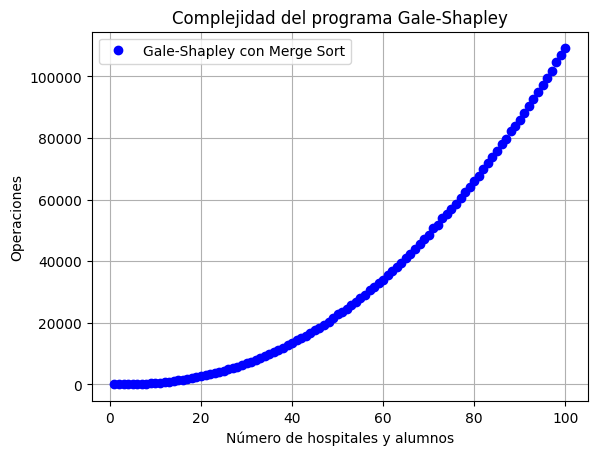

In [ ]:
import random
import matplotlib.pyplot as plt

times = 0


def merge_sort(st):
    if len(st) <= 1:
        return st

    mid = len(st) // 2

    izquierda = merge_sort(st[:mid])
    derecha = merge_sort(st[mid:])

    return merge(izquierda, derecha)


def merge(izq, der):
    global times

    resultado = []

    i = 0
    j = 0

    while i < len(izq) and j < len(der):
        times = times + 1

        if izq[i][1] > der[j][1]:
            resultado.append(izq[i])
            i = i + 1
        else:
            resultado.append(der[j])
            j = j + 1

    while i < len(izq):
        resultado.append(izq[i])
        i = i + 1

    while j < len(der):
        resultado.append(der[j])
        j = j + 1

    return resultado


def obtener_nombres(preferencias):
    preferencias_ordenadas = {}

    for persona in preferencias:
        lista = preferencias[persona]

        lista_ordenada = merge_sort(lista)

        nueva_lista = []

        for opcion in lista_ordenada:
            nombre = opcion[0]
            nueva_lista.append(nombre)

        preferencias_ordenadas[persona] = nueva_lista

    return preferencias_ordenadas


def gale_shapley(hospitales, alumnos):
    global times

    hospitales_libres = list(hospitales.keys())

    emparejamiento = {}

    siguiente_propuesta = {}

    for hospital in hospitales:
        siguiente_propuesta[hospital] = 0

    nivel_preferencias = {}

    for alumno in alumnos:
        lista = alumnos[alumno]

        nivel_preferencias[alumno] = {}

        posicion = 0

        for hospital in lista:
            nivel_preferencias[alumno][hospital] = posicion
            posicion = posicion + 1

    while len(hospitales_libres) > 0:
        hospital = hospitales_libres.pop(0)

        posicion_alumno = siguiente_propuesta[hospital]
        alumno = hospitales[hospital][posicion_alumno]

        siguiente_propuesta[hospital] = siguiente_propuesta[hospital] + 1

      
        times = times + 1

        if alumno not in emparejamiento:
            emparejamiento[alumno] = hospital
        else:
            hospital_actual = emparejamiento[alumno]

            posicion_nuevo = nivel_preferencias[alumno][hospital]
            posicion_actual = nivel_preferencias[alumno][hospital_actual]

            
            times = times + 1

            if posicion_nuevo < posicion_actual:
                emparejamiento[alumno] = hospital
                hospitales_libres.append(hospital_actual)
            else:
                hospitales_libres.append(hospital)

    resultado = {}

    for alumno in emparejamiento:
        hospital = emparejamiento[alumno]
        resultado[hospital] = alumno

    return resultado

def generar_datos(n):
    hospitales = {}
    alumnos = {}

    nombres_hospitales = []
    nombres_alumnos = []

    for i in range(n):
        nombres_hospitales.append("Hospital " + str(i + 1))
        nombres_alumnos.append("Alumno " + str(i + 1))

    for hospital in nombres_hospitales:
        lista = []

        for alumno in nombres_alumnos:
            puntaje = random.randint(1, 100)
            lista.append((alumno, puntaje))

        hospitales[hospital] = lista

    for alumno in nombres_alumnos:
        lista = []

        for hospital in nombres_hospitales:
            puntaje = random.randint(1, 100)
            lista.append((hospital, puntaje))

        alumnos[alumno] = lista

    return hospitales, alumnos

TAM = 101

eje_x = list(range(1, TAM, 1))
eje_y = []

for num in eje_x:
    hospitales, alumnos = generar_datos(num)

    times = 0

    hospitales = obtener_nombres(hospitales)
    alumnos = obtener_nombres(alumnos)

    resultado = gale_shapley(hospitales, alumnos)

    eje_y.append(times)


fig, ax = plt.subplots(facecolor='w', edgecolor='k')

ax.plot(eje_x, eje_y, marker='o', color="b", linestyle='None')

ax.set_xlabel('Número de hospitales y alumnos')
ax.set_ylabel('Operaciones')
ax.grid(True)
ax.legend(["Gale-Shapley con Merge Sort"])

plt.title('Complejidad del programa Gale-Shapley')
plt.show()

## 3.5 Pruebas

### Tabla 3. Prueba de ordenamiento de preferencias

| Caso | Entrada | Resultado esperado | Resultado |
|---|---|---|---|
| 1 | `Hospital A: [(Ana, 90), (Luis, 70), (Sofia, 85)]` | `Hospital A: [Ana, Sofia, Luis]` | Correcto |
| 2 | `Hospital B: [(Ana, 80), (Luis, 95), (Sofia, 60)]` | `Hospital B: [Luis, Ana, Sofia]` | Correcto |
| 3 | `Hospital C: [(Ana, 75), (Luis, 65), (Sofia, 100)]` | `Hospital C: [Sofia, Ana, Luis]` | Correcto |
| 4 | `Ana: [(Hospital A, 95), (Hospital B, 80), (Hospital C, 70)]` | `Ana: [Hospital A, Hospital B, Hospital C]` | Correcto |
| 5 | `Luis: [(Hospital A, 60), (Hospital B, 100), (Hospital C, 75)]` | `Luis: [Hospital B, Hospital C, Hospital A]` | Correcto |
| 6 | `Sofia: [(Hospital A, 85), (Hospital B, 65), (Hospital C, 90)]` | `Sofia: [Hospital C, Hospital A, Hospital B]` | Correcto |

### Tabla 4. Prueba principal del programa

| Elemento | Preferencias originales | Preferencias ordenadas |
|---|---|---|
| Hospital A | Ana 90, Luis 70, Sofia 85 | Ana, Sofia, Luis |
| Hospital B | Ana 80, Luis 95, Sofia 60 | Luis, Ana, Sofia |
| Hospital C | Ana 75, Luis 65, Sofia 100 | Sofia, Ana, Luis |
| Ana | Hospital A 95, Hospital B 80, Hospital C 70 | Hospital A, Hospital B, Hospital C |
| Luis | Hospital A 60, Hospital B 100, Hospital C 75 | Hospital B, Hospital C, Hospital A |
| Sofia | Hospital A 85, Hospital B 65, Hospital C 90 | Hospital C, Hospital A, Hospital B |

### Tabla 5. Emparejamiento esperado del caso principal

| Hospital | Alumno asignado | Justificacion |
|---|---|---|
| Hospital A | Ana | Hospital A propone a Ana y Ana lo prefiere sobre los otros hospitales. |
| Hospital B | Luis | Hospital B propone a Luis y Luis lo tiene como primera opcion. |
| Hospital C | Sofia | Hospital C propone a Sofia y Sofia lo tiene como primera opcion. |

Resultado esperado:

```text
Hospital A - Ana
Hospital B - Luis
Hospital C - Sofia
```

### Tabla 6. Casos de prueba adicionales

| Caso | Descripcion | Entrada resumida | Resultado esperado |
|---|---|---|---|
| 1 | Caso minimo | 1 hospital y 1 alumno. Ambos se prefieren entre si. | `Hospital 1 - Alumno 1` |
| 2 | Caso principal | 3 hospitales y 3 alumnos con las preferencias del programa. | `Hospital A - Ana`, `Hospital B - Luis`, `Hospital C - Sofia` |
| 3 | Conflicto por el mismo alumno | H1 y H2 proponen primero a A1, pero A1 prefiere H2. | `H2 - A1`, `H1 - A2` |
| 4 | Rechazo de propuesta | Un alumno ya emparejado rechaza a un hospital que prefiere menos. | El hospital rechazado propone a su siguiente opcion. |
| 5 | Preferencias vacias | Diccionarios de hospitales y alumnos vacios. | `{}` |

### Tabla 7. Prueba de estabilidad

| Pareja final | Revision | Cumple |
|---|---|---|
| Hospital A - Ana | Ana prefiere Hospital A sobre Hospital B y Hospital C. | Si |
| Hospital B - Luis | Luis prefiere Hospital B sobre Hospital A y Hospital C. | Si |
| Hospital C - Sofia | Sofia prefiere Hospital C sobre Hospital A y Hospital B. | Si |




